In [1]:
# ==================== IMPORTS ====================
import pandas as pd 
import kagglehub as kh
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

# ==================== DOWNLOAD & LOAD DATA ====================
# Download dataset from KaggleHub
path = kh.dataset_download("shayanfazeli/heartbeat")

def load_data(path):
    mitbih_train = pd.read_csv(os.path.join(path, "mitbih_train.csv"), header=None)
    mitbih_test = pd.read_csv(os.path.join(path, "mitbih_test.csv"), header=None)
    ptbdb_normal = pd.read_csv(os.path.join(path, "ptbdb_normal.csv"), header=None)
    ptbdb_abnormal = pd.read_csv(os.path.join(path, "ptbdb_abnormal.csv"), header=None)
    return mitbih_train, mitbih_test, ptbdb_normal, ptbdb_abnormal

mitbih_train, mitbih_test, ptbdb_normal, ptbdb_abnormal = load_data(path)

# ==================== ASSIGN LABELS FOR PTBDB ====================
def replace_label_column(data, label):
    data.iloc[:, -1] = label
    return data

ptbdb_normal = replace_label_column(ptbdb_normal, 6)  # normal
ptbdb_abnormal = replace_label_column(ptbdb_abnormal, 7)  # abnormal

ptbdb_all = pd.concat([ptbdb_normal, ptbdb_abnormal], ignore_index=True)

# ==================== SPLIT PTBDB ONLY ====================
X_ptbdb_train, X_ptbdb_test, y_ptbdb_train, y_ptbdb_test = train_test_split(
    ptbdb_all.iloc[:, :-1], ptbdb_all.iloc[:, -1], test_size=0.2, random_state=42
)

# ==================== COMBINE WITH MITBIH ====================
X_train_df = pd.concat([X_ptbdb_train, mitbih_train.iloc[:, :-1]], ignore_index=True)
y_train = pd.concat([y_ptbdb_train, mitbih_train.iloc[:, -1]], ignore_index=True)

X_test_df = pd.concat([X_ptbdb_test, mitbih_test.iloc[:, :-1]], ignore_index=True)
y_test = pd.concat([y_ptbdb_test, mitbih_test.iloc[:, -1]], ignore_index=True)

# ==================== LABEL REMAPPING ====================
# Merge class 6 into 0 ("Normal"), rename 7 to 5 ("Abnormal")
y_train = y_train.astype(int).replace({6: 0, 7: 5}).reset_index(drop=True)
y_test = y_test.astype(int).replace({6: 0, 7: 5}).reset_index(drop=True)

# ==================== DROP LOW-INFORMATION COLUMNS ====================
def drop_almost_zero_columns(X, threshold=0.8):
    zero_fraction = (X == 0).sum() / len(X)
    drop_cols = zero_fraction[zero_fraction >= threshold].index
    return X.drop(columns=drop_cols)

X_train_df = drop_almost_zero_columns(X_train_df)
X_test_df = drop_almost_zero_columns(X_test_df)

# ==================== CONVERT TO NUMPY ====================
X_train = X_train_df.values
X_test = X_test_df.values
y_train = y_train.values
y_test = y_test.values

# ==================== SPLIT TRAIN -> TRAIN + VALIDATION ====================
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# ==================== NORMALIZATION ====================
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_final)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# ==================== RESHAPE FOR CNN INPUT ====================
X_train_final = X_train_final.reshape((X_train_final.shape[0], X_train_final.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ==================== ONE-HOT ENCODE LABELS ====================
# Infer number of classes from all combined y
all_labels = np.concatenate([y_train, y_test])
unique_classes = np.unique(all_labels)
num_classes = len(unique_classes)

y_train_cat = to_categorical(y_train_final, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# ==================== CLASS WEIGHTS (Manually Defined) ====================
class_weights = {
    0: 1.0,   # Normal
    1: 4.0,   # Supraventricular
    2: 1.5,   # Ventricular
    3: 5.0,   # Fusion
    4: 1.0,   # Unknown
    5: 1.2    # Abnormal
}

# ==================== HUMAN READABLE CONDITIONS (Optional Mapping) ====================
conditions = {
    0: "Normal (N)",
    1: "Supraventricular premature (S)",
    2: "Premature ventricular contraction (V)",
    3: "Fusion of ventricular and normal beat (F)",
    4: "Unclassifiable beat (Q)",
    5: "Abnormal (A)"
}


c:\Users\hawra\anaconda3\envs\tf-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Loss
import tensorflow.keras.backend as K

class FocalLoss(Loss):
    def __init__(self, gamma=2.0, alpha=0.5):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        weight = self.alpha * K.pow(1 - y_pred, self.gamma)
        return K.sum(weight * cross_entropy, axis=1)

def build_model(units, learning_rate, input_shape, num_classes):
    model = Sequential([
        Conv1D(32, kernel_size=5, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Flatten(),
        Dense(units, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss=FocalLoss(), metrics=['accuracy'])
    return model


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
import time
import numpy as np

# Define hyperparameter sets
param_sets = [
    {"units": 64, "learning_rate": 0.001},
    {"units": 128, "learning_rate": 0.0005},
    {"units": 256, "learning_rate": 0.0001}
]

histories = []
models = []
training_times = []

for params in param_sets:
    print(f"\nTraining with: units={params['units']}, lr={params['learning_rate']}")
    model = build_model(params['units'], params['learning_rate'],
                        input_shape=(X_train_final.shape[1], 1), num_classes=num_classes)
    
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    start_time = time.time()
    history = model.fit(
        X_train_final, y_train_cat,
        epochs=30,
        batch_size=128,
        validation_data=(X_val, y_val_cat),
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=1
    )
    duration = time.time() - start_time
    training_times.append(duration)

    label = f"units={params['units']}, lr={params['learning_rate']}"
    print(f"Training time: {duration:.2f}s")
    
    models.append(model)
    histories.append((label, history))



Training with: units=64, lr=0.001


c:\Users\hawra\anaconda3\envs\tf-env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8072 - loss: 0.2656 - val_accuracy: 0.8807 - val_loss: 0.0795
Epoch 2/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8664 - loss: 0.1366 - val_accuracy: 0.9049 - val_loss: 0.0571
Epoch 3/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8810 - loss: 0.1136 - val_accuracy: 0.9204 - val_loss: 0.0491
Epoch 4/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8942 - loss: 0.0922 - val_accuracy: 0.9304 - val_loss: 0.0394
Epoch 5/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9027 - loss: 0.0837 - val_accuracy: 0.9343 - val_loss: 0.0372
Epoch 6/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9117 - loss: 0.0737 - val_accuracy: 0.9467 - val_loss: 0.0322
Epoch 7/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9207 - loss: 0.0667 - val_accuracy: 0.9483 - val_loss: 0.0291
Epoch 8/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9240 - loss: 0.0610 - val_accuracy: 0.

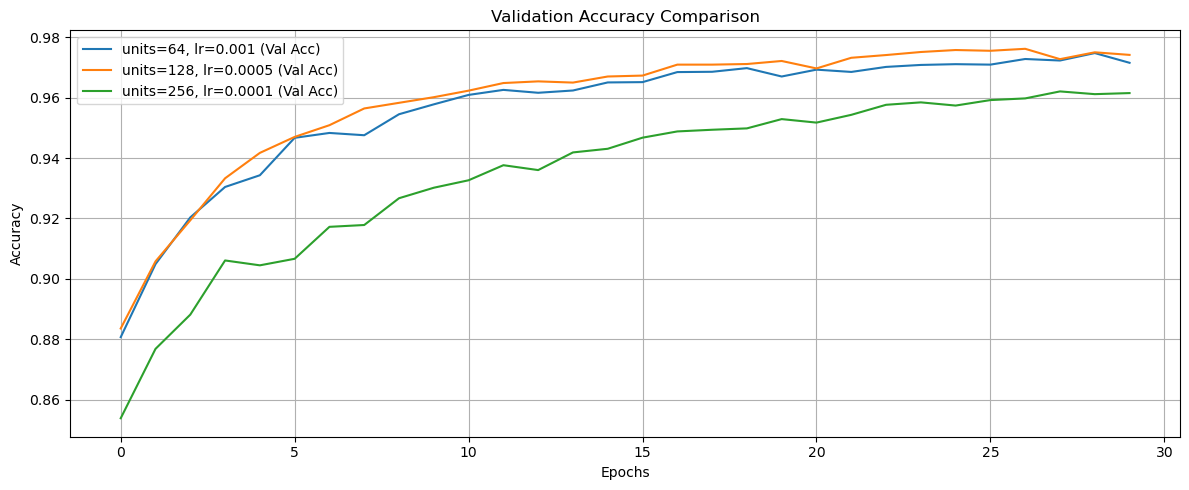

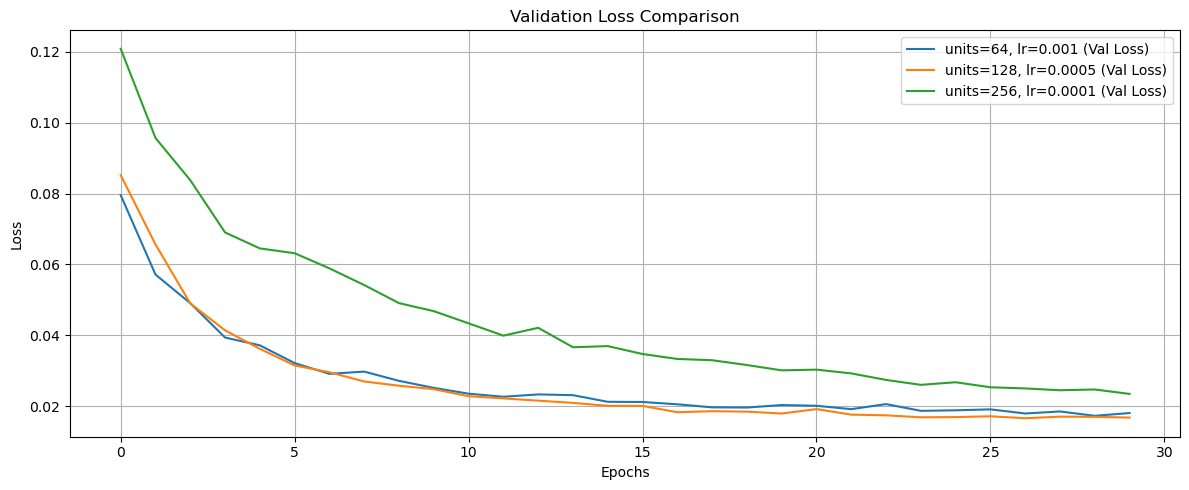

In [5]:
# Plot Validation Accuracy
plt.figure(figsize=(12, 5))
for label, history in histories:
    plt.plot(history.history['val_accuracy'], label=f"{label} (Val Acc)")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Validation Loss
plt.figure(figsize=(12, 5))
for label, history in histories:
    plt.plot(history.history['val_loss'], label=f"{label} (Val Loss)")
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


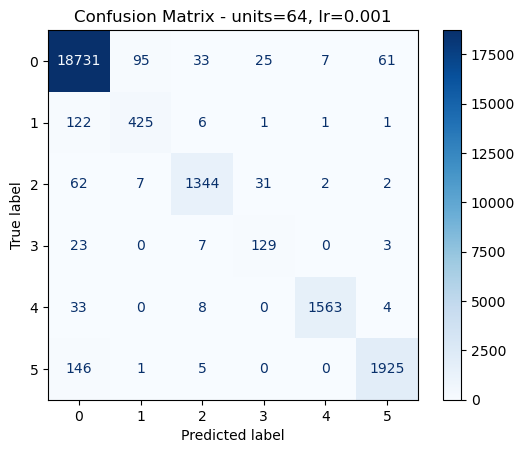

776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


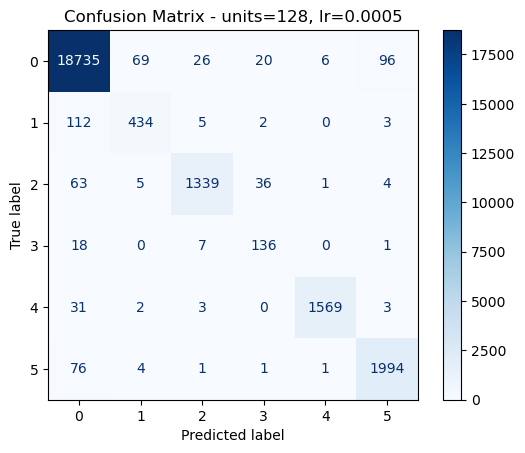

776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


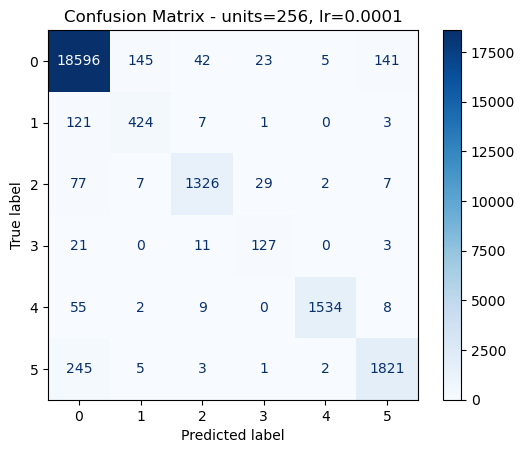

In [6]:
for idx, (label, _) in enumerate(histories):
    model = models[idx]
    y_pred = np.argmax(model.predict(X_test), axis=1)

    cm = confusion_matrix(np.argmax(y_test_cat, axis=1), y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {label}")
    plt.grid(False)
    plt.show()


776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


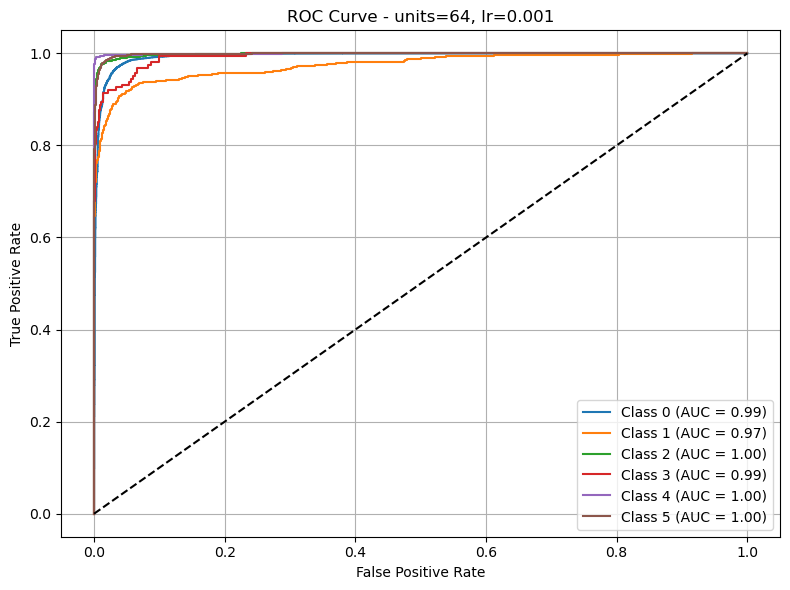

776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


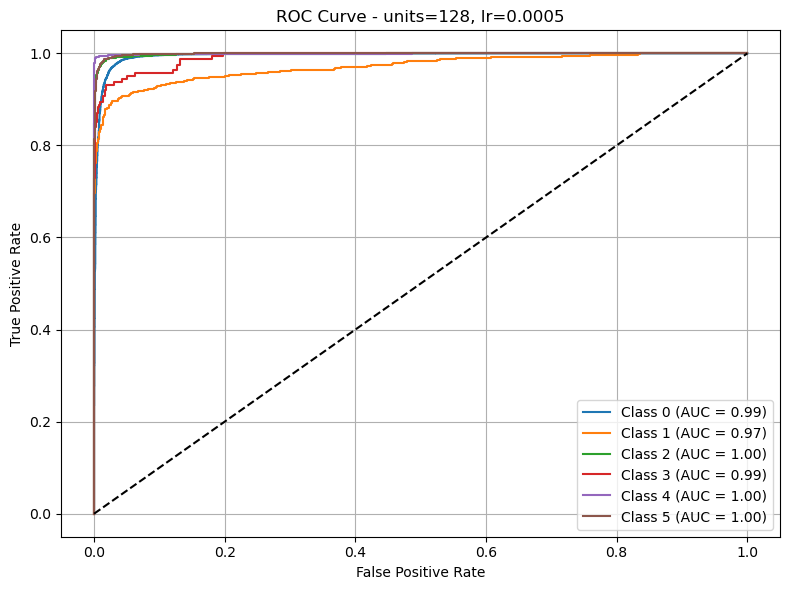

776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


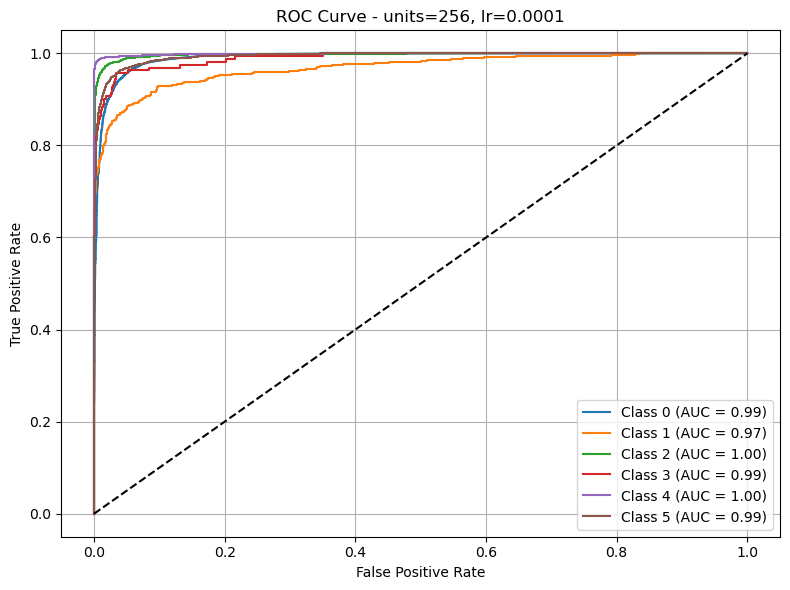

In [7]:
y_test_bin = label_binarize(np.argmax(y_test_cat, axis=1), classes=range(num_classes))

for idx, (label, _) in enumerate(histories):
    model = models[idx]
    y_pred_prob = model.predict(X_test)

    plt.figure(figsize=(8, 6))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve - {label}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [8]:
print("\nTraining Time Summary:")
for idx, (label, _) in enumerate(histories):
    print(f"{label}: {training_times[idx]:.2f} seconds")



Training Time Summary:
units=64, lr=0.001: 102.91 seconds
units=128, lr=0.0005: 114.88 seconds
units=256, lr=0.0001: 133.11 seconds
